In [9]:
import pandas as pd
from scipy import stats
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
import matplotlib.pyplot as plt
import seaborn as sns
from fitter import Fitter

   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42     Florida  166187.94
Best distribution (BIC): norm


2026-03-12 20:06:22.139 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted norm: error=0.000000, AIC=1205.31, KS=0.0870
2026-03-12 20:06:22.148 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted expon: error=0.000000, AIC=1252.59, KS=0.3232
2026-03-12 20:06:22.158 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted lognorm: error=0.000000, AIC=1207.30, KS=0.0853
2026-03-12 20:06:22.325 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted gamma: error=0.000000, AIC=1207.30, KS=0.0854


This directly shows you the BIC values for each distribution
         sumsquare_error          aic          bic    kl_div  ks_statistic  \
lognorm     8.159470e-09  1207.304978  1213.041047  5.788645      0.085320   
gamma       8.159791e-09  1207.304910  1213.040979  5.788356      0.085435   
norm        8.163438e-09  1205.309727  1209.133773  5.783891      0.086995   
expon       1.036621e-08  1252.587528  1256.411574  7.471683      0.323230   

         ks_pvalue  
lognorm   0.829656  
gamma     0.828471  
norm      0.812114  
expon     0.000038  
Get the parameters of the single best distribution
{'norm': {'loc': np.float64(112012.63920000002), 'scale': np.float64(39901.082816672824)}}


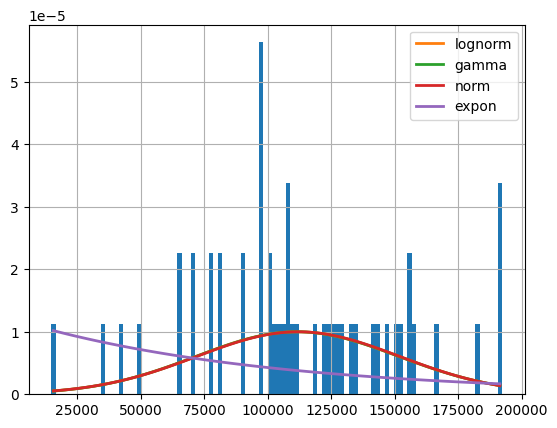

In [33]:
#Load the data
df = pd.read_csv("50_Startups.csv")
print(df.head())
#import scipy.stats as stats


# --- 1. BIC DISTRIBUTION FITTING FOR 'PROFIT' ---
# We define a list of common probability distributions to test against your Profit data
dist_names = ['norm', 'lognorm', 'gamma', 'expon']
best_dist, best_bic = None, float('inf') # Initialize placeholders for the best result

for name in dist_names:
    dist = getattr(stats, name) # Get the distribution function from scipy
    params = dist.fit(df['Profit']) # Estimate distribution parameters (mean, std, etc.)
    #print("dist: ", dist)
    
    # Calculate Log-Likelihood: how well the distribution explains the data
    log_lik = np.sum(dist.logpdf(df['Profit'], *params))
    
    # BIC Formula: -2 * log_likelihood + (number of parameters) * log(sample size)
    # This penalizes complex models to prevent overfitting
    k = len(params) # Number of parameters in the distribution
    n = len(df['Profit']) # Number of startups (50)
    bic = -2 * log_lik + k * np.log(n)
    
    if bic < best_bic: # The distribution with the LOWEST BIC is the best fit
        best_bic, best_dist = bic, name

print(f"Best distribution (BIC): {best_dist}")

# using fitter library get BIC
from fitter import Fitter

# 1. Initialize Fitter with your 'Profit' data
# You can specify common distributions or let it try all 80+ from scipy
f = Fitter(df['Profit'], distributions=['norm', 'lognorm', 'gamma', 'expon'])

# 2. Perform the fit
f.fit()

# 3. Get a summary table ranked by BIC (or other metrics)
# This directly shows you the BIC values for each distribution
print("This directly shows you the BIC values for each distribution")
print(f.summary())

# 4. Get the parameters of the single best distribution
print("Get the parameters of the single best distribution")
print(f.get_best(method='bic'))



X_const
   const  R&D Spend  Administration  Marketing Spend
0    1.0  165349.20       136897.80        471784.10
1    1.0  162597.70       151377.59        443898.53
2    1.0  153441.51       101145.55        407934.54
3    1.0  144372.41       118671.85        383199.62
4    1.0  142107.34        91391.77        366168.42

VIF Scores:
            Feature        VIF
0            const  25.338950
1        R&D Spend   2.468903
2   Administration   1.175091
3  Marketing Spend   2.326773

Durbin-Watson: 1.28
Breusch-Pagan p-value: 0.3729
Influential Outliers (indices): [45 48 49]
see the plot for all 3 ['R&D Spend', 'Administration', 'Marketing Spend']


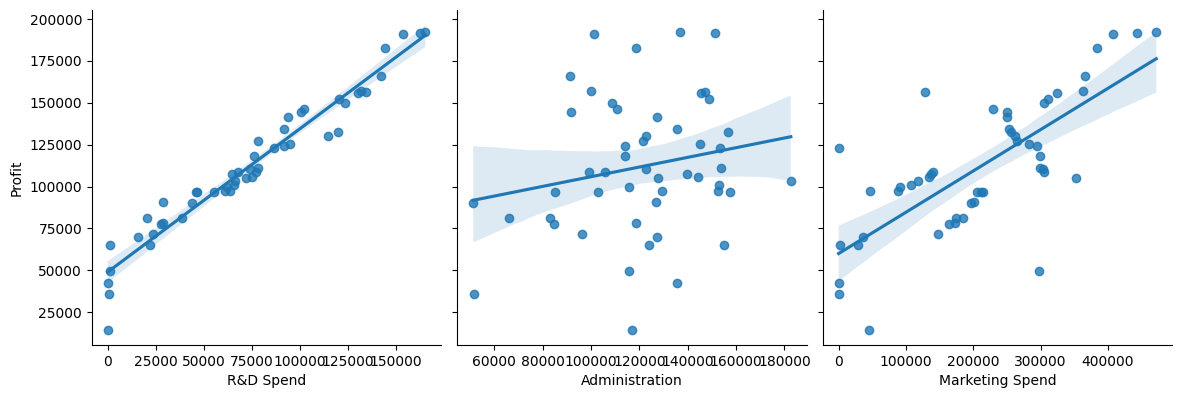

In [34]:

# --- 2. PREPARING THE REGRESSION MODEL ---
# Regression requires a constant (intercept) to be added manually in statsmodels
"""
1. The Intercept (sm.add_constant)
Why? In the equation Y=Mx+C, the C is the intercept (the value of Profit if all spends were zero).
Scikit-Learn adds this automatically behind the scenes.
Statsmodels (the library used for statistical tests) does not. If you don't add a constant, the model is forced to go through (0,0)
, which is usually inaccurate and will bias your other coefficients (R&D, Admin, etc.).
sm.add_constant(X) adds a column of 1s to your data so the model can calculate that baseline Profit value.
"""
# Step A: Select your 3 independent attributes
X = df[['R&D Spend', 'Administration', 'Marketing Spend']] # Independent variables
# Step B: Create a NEW variable that includes those 3 PLUS a column of 1s
X_const = sm.add_constant(X) # Adds a column of 1s representing the 'y-intercept'
y = df['Profit'] # Dependent variable (Target)
print("X_const") 
print(X_const.head())
# Fit an Ordinary Least Squares (OLS) model to extract residuals for testing
# Step C: Pass that new combined variable to the model
model = sm.OLS(y, X_const).fit()

# --- 3. MULTICOLLINEARITY (VIF) ---
# VIF measures how much one predictor (e.g., R&D) is explained by others, that why it passes all X.values and 1 independent variable 
# at a time in function variance_inflation_factor.
# High VIF (>5 or 10) means variables are redundant and hurt model stability
"""
1. The VIF Rule of Thumb:
VIF = 1: No correlation (Perfect).
VIF 1 to 5: Moderate correlation (Usually acceptable).
VIF > 5 or 10: High multicollinearity (Problematic). You should consider dropping this variable because it's redundant.
"""
vif_values = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
vif_data = pd.DataFrame({'Feature': X_const.columns, 'VIF': vif_values})
print("\nVIF Scores:\n", vif_data)

# --- 4. AUTOCORRELATION (DURBIN-WATSON) before model fitting--- We should not doing it before model fitting
# Tests if the errors are independent. Important if data has a sequence/order.
# Result ~2.0 means no autocorrelation; <1.5 or >2.5 indicates a problem.
#dw_stat = sm.stats.stattools.durbin_watson(model.resid)
#print(f"\nDurbin-Watson: {dw_stat:.2f}")

# --- 5. HOMOSCEDASTICITY (BREUSCH-PAGAN) --- post model fitting
# Checks if the variance of errors is constant across all levels of X.
# If p < 0.05, you have 'Heteroscedasticity' (uneven variance), which is bad.
#_, p_val, _, _ = het_breuschpagan(model.resid, X_const)
#print(f"Breusch-Pagan p-value: {p_val:.4f}")

# --- 6. OUTLIERS (COOK'S DISTANCE) ---
# Cook's distance measures how much the model changes if a specific row is deleted.
# A common threshold for an 'influential outlier' is 4 divided by the number of rows.
influence = model.get_influence()
(c, _) = influence.cooks_distance
outliers = np.where(c > (4 / len(df))) # Returns indices of startups that skew the model
print(f"Influential Outliers (indices): {outliers[0]}")

# --- 7. LINEARITY (VISUALIZATION) ---
# Creates scatter plots with a regression line to see if X and Y move together linearly.
sns.pairplot(df, x_vars=['R&D Spend', 'Administration', 'Marketing Spend'], 
             y_vars='Profit', height=4, aspect=1, kind='reg')
print("see the plot for all 3 ['R&D Spend', 'Administration', 'Marketing Spend']")
plt.show()




In [25]:
# 2. Convert 'State' to numbers so the model can process it
# This takes your 'State' column and turns it into 0s and 1s((One-Hot Encoding).)
# drop_first=True: This is a critical statistical step called avoiding the "Dummy Variable Trap." 
#If you know a startup isn't in Florida or New York, it must be in California. 
#Including all three causes "perfect multicollinearity," which breaks the math of your regression.
# pd.get_dummies sorts the unique values in the State column alphabetically: California, Florida, New York.
# When you tell it to drop_first=True, it drops the first alphabetically, which is California.
# Is the California data "gone"?
#No. The information is still there, just "hidden" in the zero-values.
#Look at your data in Row 1:
#State_Florida = False (0)
#State_New York = False (0)
#Mathematical Conclusion: Since it is not in Florida and not in New York, the model knows with 100% certainty that this startup 
#is in California.
"""
Summary of the "Reference" Category
In your model, California is now the Reference (Baseline).
The coefficient for State_Florida will tell you: "How much MORE profit does a Florida startup make compared to a California startup?"
If you kept all three, the math would "break" because the columns would perfectly sum to 1 (the Dummy Variable Trap).

"""
X = pd.get_dummies(df.drop('Profit', axis=1), drop_first=True)
print(X.head())
y = df['Profit']

# 3. 80/20 Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Standardize (The "Scaling" step)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Fit & Predict
regressor = LinearRegression()
regressor.fit(X_train_scaled, y_train)
y_pred = regressor.predict(X_test_scaled)

print("Predictions completed for the 20% test set!")

# 6. Evaluation Metrics
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print(f"R-Squared Score: {r2:.4f}")
print(f"Model Coefficients: {regressor.coef_}")
print(f"Model Intercept: {regressor.intercept_:.2f}")

# Compare Actual vs Predicted for the Test Set
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred.round(2)})
print("\nFirst 5 Predictions:\n", comparison.head())

   R&D Spend  Administration  Marketing Spend  State_Florida  State_New York
0  165349.20       136897.80        471784.10          False            True
1  162597.70       151377.59        443898.53          False           False
2  153441.51       101145.55        407934.54           True           False
3  144372.41       118671.85        383199.62          False            True
4  142107.34        91391.77        366168.42           True           False
Predictions completed for the 20% test set!
R-Squared Score: 0.8987
Model Coefficients: [ 3.81022693e+04 -1.86475430e+03  3.38617581e+03  4.47775725e+02
  3.27289103e+00]
Model Intercept: 115651.72

First 5 Predictions:
        Actual  Predicted
13  134307.35  126362.88
39   81005.76   84608.45
30   99937.59   99677.49
45   64926.08   46357.46
17  125370.37  128750.48


In [35]:
# Check for autocorrelation -- what is it--?
import statsmodels.api as sm

# 1. Calculate residuals for the Training set
# We use training data because that's where the model 'learned' the patterns
y_train_pred = regressor.predict(X_train_scaled)
train_residuals = y_train - y_train_pred

# 2. Perform the Durbin-Watson test
# This checks if the error in one row is related to the error in the next row
dw_score = sm.stats.stattools.durbin_watson(train_residuals)

print(f"\nDurbin-Watson Statistic: {dw_score:.4f}")

# 3. Interpret the result
if 1.5 <= dw_score <= 2.5:
    print("Interpretation: No significant autocorrelation detected (Good).")
elif dw_score < 1.5:
    print("Interpretation: Positive autocorrelation detected (Potential issue).")
else:
    print("Interpretation: Negative autocorrelation detected (Potential issue).")



Durbin-Watson Statistic: 1.7510
Interpretation: No significant autocorrelation detected (Good).


In [37]:
# check for Homoscedasticity 
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# 1. Calculate the residuals (errors) for the training data
# Residual = Actual Profit - Predicted Profit
y_train_pred = regressor.predict(X_train_scaled)
residuals = y_train - y_train_pred

# 2. Add a constant to the scaled training features
# The Breusch-Pagan test requires an intercept/constant column to run its internal regression
X_train_with_const = sm.add_constant(X_train_scaled)

# 3. Perform the Breusch-Pagan test
# This function returns 4 values: Lagrange Multiplier, p-value, f-statistic, and f-p-value
bp_test = het_breuschpagan(residuals, X_train_with_const)

# 4. Extract the p-value (it is the second value in the resulting list)
# A p-value > 0.05 means we "Fail to Reject" the null hypothesis of constant variance
bp_p_value = bp_test[1]

print(f"\nBreusch-Pagan Test p-value: {bp_p_value:.4f}")

# 5. Interpret the result for your 50 startups data
if bp_p_value > 0.05:
    print("Interpretation: Homoscedasticity confirmed (The error variance is constant).")
else:
    print("Interpretation: Heteroscedasticity detected (The error variance changes with data scale).")



Breusch-Pagan Test p-value: 0.7781
Interpretation: Homoscedasticity confirmed (The error variance is constant).


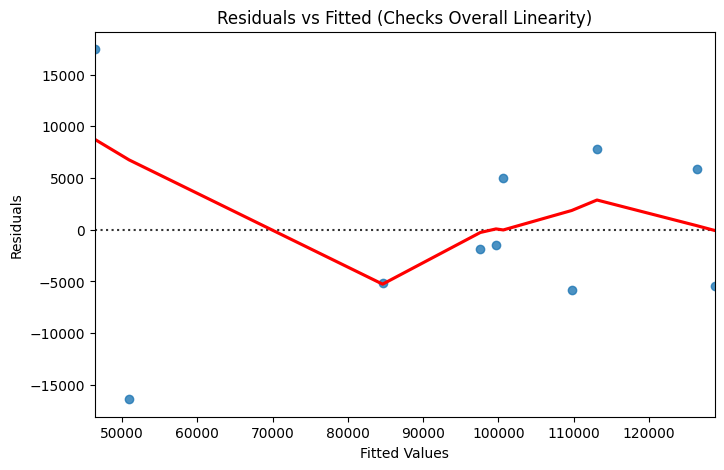

below pair plot


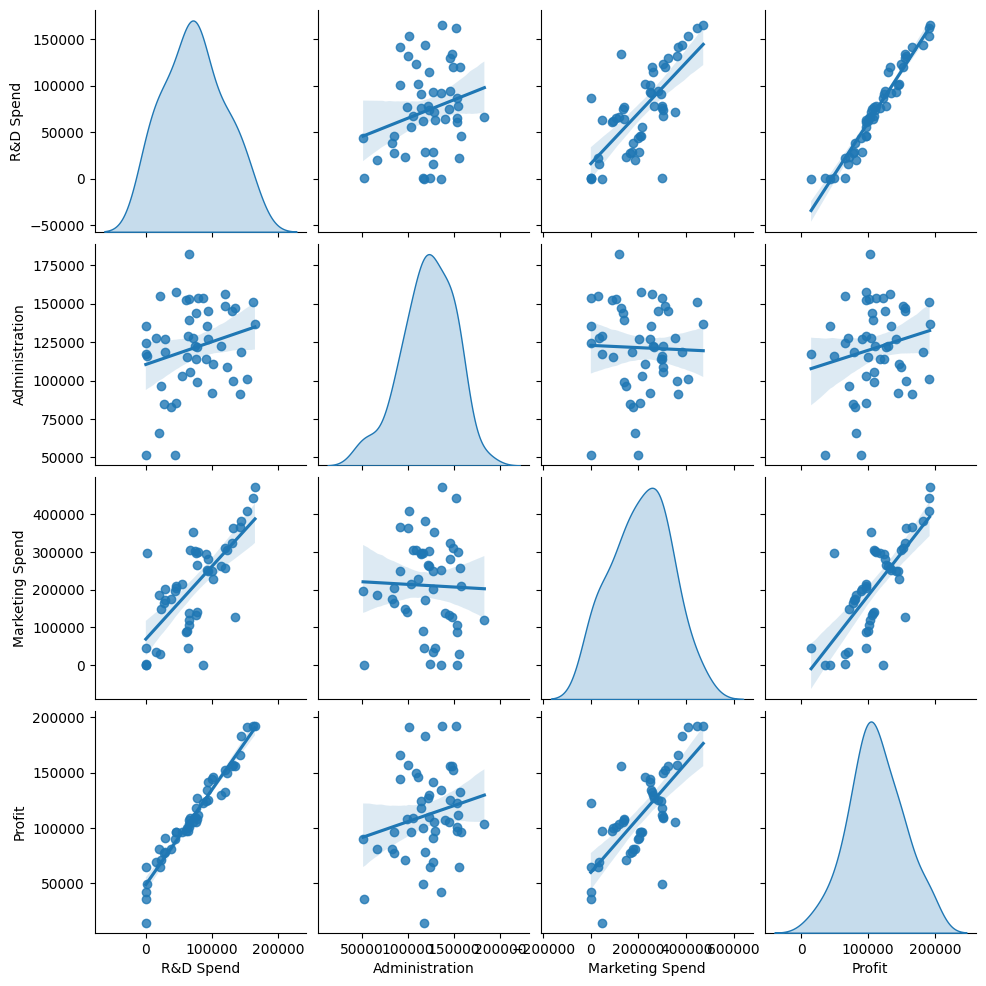

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
# Below are the 2 methods to check linearity of my data.
# --- METHOD 1: RESIDUALS VS FITTED PLOT ---
# Create a new figure with specific dimensions (8 inches wide, 5 inches high)
plt.figure(figsize=(8, 5))

# Plot the predicted values (x) against the errors (y). 
# 'lowess=True' adds a smooth local regression line to help spot non-linear patterns.
# 'line_kws' colors that smooth line red for better visibility.
sns.residplot(x=y_pred, y=(y_test - y_pred), lowess=True, line_kws={'color': 'red'})

# Set the chart title to explain what we are checking (Overall Linearity)
plt.title('Residuals vs Fitted (Checks Overall Linearity)')

# Label the x-axis as 'Fitted Values' (these are the model's Profit predictions)
plt.xlabel('Fitted Values')

# Label the y-axis as 'Residuals' (the difference: Actual Profit - Predicted Profit)
plt.ylabel('Residuals')

# Display the final Residplot on the screen
plt.show()
#--------------------------------------------------------------------------------------------------------------------------
print("below pair plot")
# So, in this it will compare each field/variable with all other variables. like R&D will be compared with 
# Marketing and administrator and profit.
# --- METHOD 2: PAIRPLOT ---
# Create a matrix of scatter plots for every numerical column in your startup dataframe.
# 'kind=reg' adds a linear regression line to every individual scatter plot.
# 'diag_kind=kde' shows the distribution (density curve) of each variable on the diagonal.
sns.pairplot(df, kind='reg', diag_kind='kde')

# Display the entire pairplot matrix
plt.show()
